In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sonalwagh/airline-loyalty-data-dictionary/Airline Loyalty Data Dictionary.csv
/kaggle/input/datasets/sonalwagh/customer-flight-activity/Customer Flight Activity.csv
/kaggle/input/datasets/sonalwagh/customer-loyalty-history/Customer Loyalty History.csv
/kaggle/input/datasets/sonalwagh/calendar/Calendar.csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)

In [4]:
loyalty = pd.read_csv('/kaggle/input/datasets/sonalwagh/customer-loyalty-history/Customer Loyalty History.csv')
activity = pd.read_csv('/kaggle/input/datasets/sonalwagh/customer-flight-activity/Customer Flight Activity.csv')
calendar = pd.read_csv('/kaggle/input/datasets/sonalwagh/calendar/Calendar.csv')

In [5]:
loyalty.head()
loyalty.info()
loyalty.describe()
loyalty.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

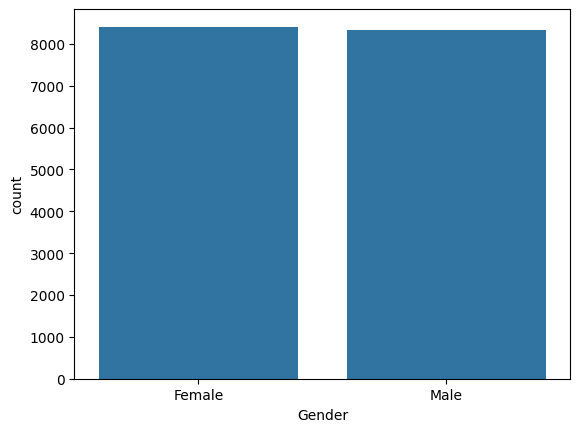

In [6]:
sns.countplot(data=loyalty,x='Gender')

<Axes: xlabel='Salary', ylabel='Count'>

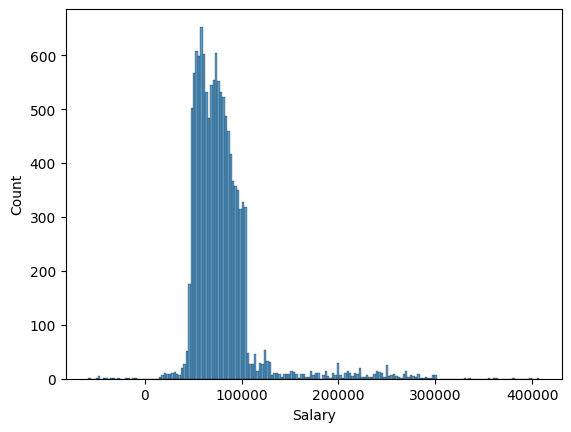

In [7]:
sns.histplot(loyalty['Salary'])

In [8]:
loyalty['Education'].value_counts()

Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Name: count, dtype: int64

In [9]:
loyalty['Loyalty Card'].value_counts()

Loyalty Card
Star      7637
Nova      5671
Aurora    3429
Name: count, dtype: int64

<Axes: xlabel='Loyalty Card', ylabel='CLV'>

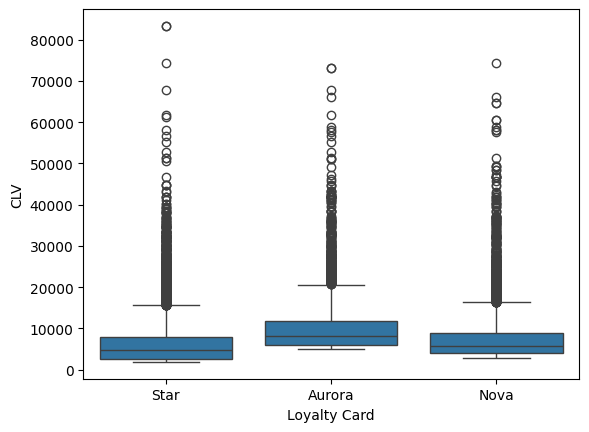

In [10]:
sns.boxplot(
    data=loyalty,
    x='Loyalty Card',
    y='CLV'
)

In [11]:
activity.groupby('Month')['Total Flights'].sum()

Month
1     26384
2     26908
3     38048
4     31284
5     46035
6     57344
7     64248
8     55784
9     39473
10    37154
11    35418
12    50728
Name: Total Flights, dtype: int64

In [12]:
activity.groupby('Month')['Distance'].sum()

Month
1     39761568
2     40115592
3     57106726
4     46938711
5     68715163
6     85954396
7     96590333
8     83529205
9     59397858
10    55512426
11    53165387
12    76074382
Name: Distance, dtype: int64

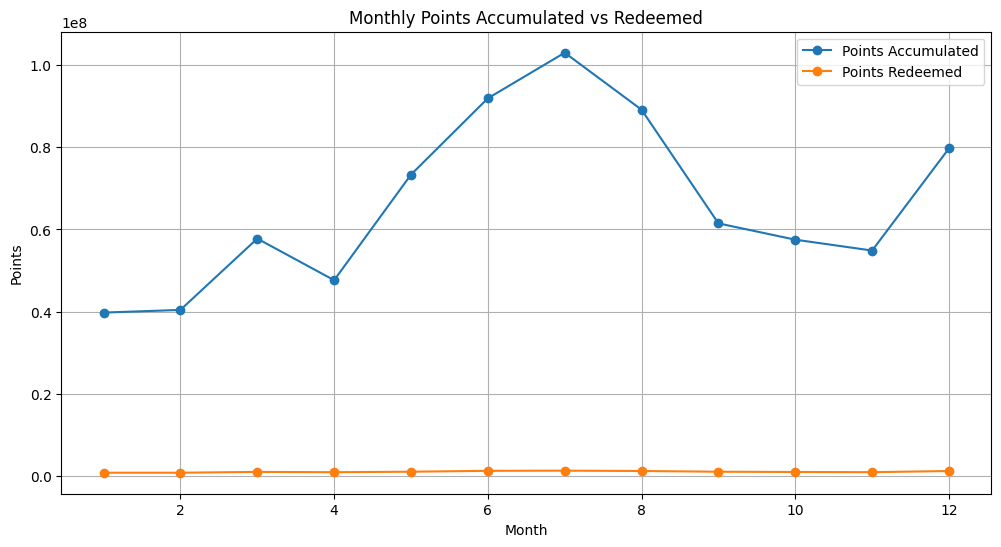

In [13]:
monthly_points = activity.groupby('Month').agg({
    'Points Accumulated':'sum',
    'Points Redeemed':'sum'
}).reset_index()

plt.figure(figsize=(12,6))

plt.plot(monthly_points['Month'],
         monthly_points['Points Accumulated'],
         marker='o',
         label='Points Accumulated')

plt.plot(monthly_points['Month'],
         monthly_points['Points Redeemed'],
         marker='o',
         label='Points Redeemed')

plt.title('Monthly Points Accumulated vs Redeemed')
plt.xlabel('Month')
plt.ylabel('Points')
plt.legend()
plt.grid(True)

plt.show()

In [16]:
customer_summary = activity.groupby(
    'Loyalty Number'
).agg({
    'Total Flights':'sum',
    'Distance':'sum',
    'Points Accumulated':'sum',
    'Points Redeemed':'sum',
    'Dollar Cost Points Redeemed':'sum'
}).reset_index()

In [17]:
master = loyalty.merge(
    customer_summary,
    on='Loyalty Number',
    how='left'
)

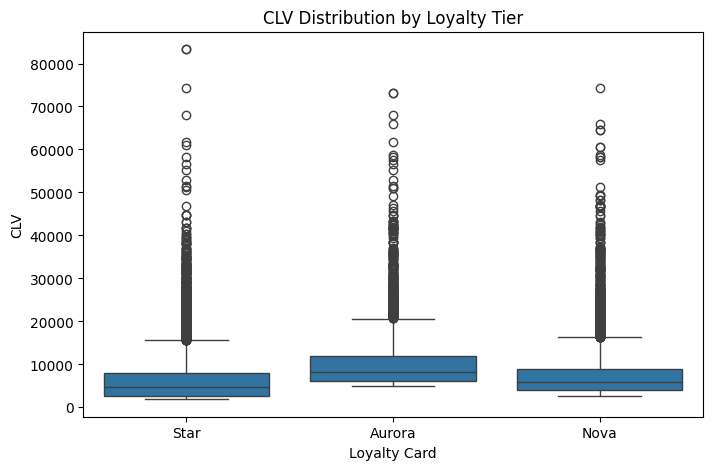

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=master,
    x='Loyalty Card',
    y='CLV'
)

plt.title('CLV Distribution by Loyalty Tier')
plt.show()

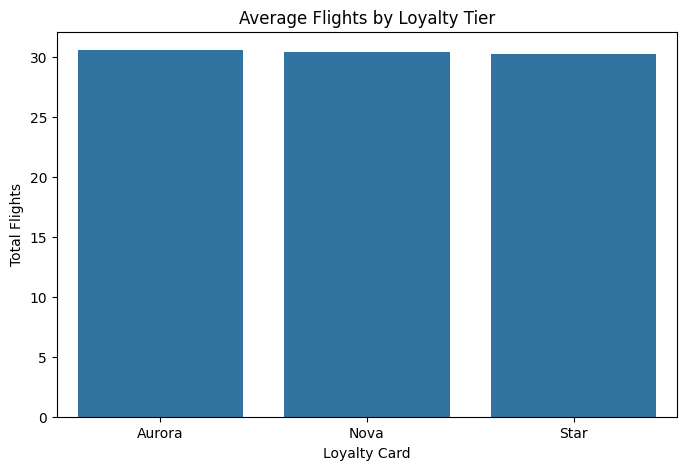

In [19]:
tier_flights = master.groupby('Loyalty Card')['Total Flights'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=tier_flights,
    x='Loyalty Card',
    y='Total Flights'
)

plt.title('Average Flights by Loyalty Tier')
plt.show()

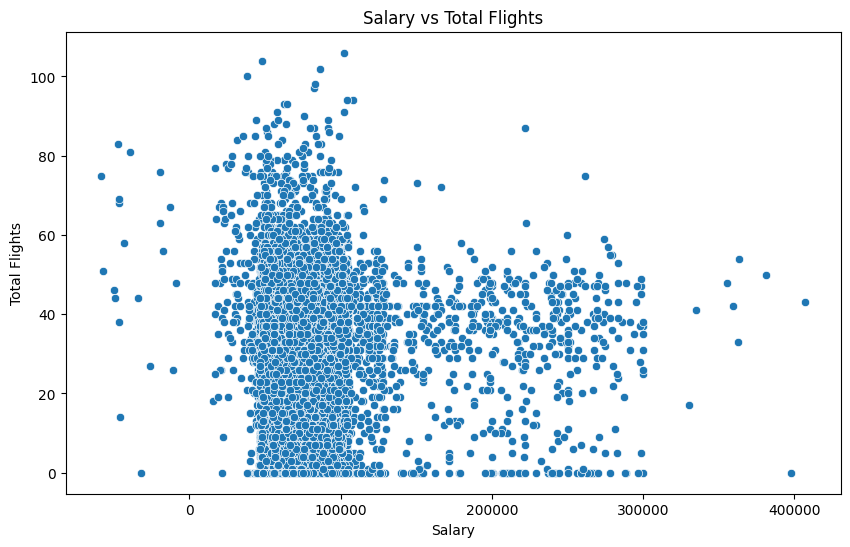

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master,
    x='Salary',
    y='Total Flights'
)

plt.title('Salary vs Total Flights')
plt.show()

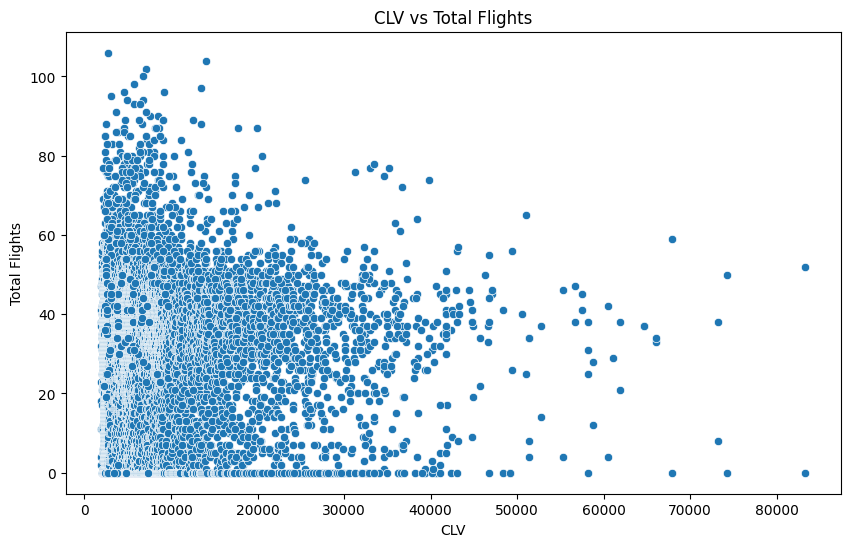

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master,
    x='CLV',
    y='Total Flights'
)

plt.title('CLV vs Total Flights')
plt.show()

In [44]:
master['Redemption Ratio'] = np.where(
    master['Points Accumulated'] > 0,
    master['Points Redeemed'] / master['Points Accumulated'],
    0
)

In [45]:
master['Distance Per Flight'] = (
    master['Distance'] /
    (master['Total Flights'] + 1)
)

In [46]:
master['Points Per Flight'] = (
    master['Points Accumulated'] /
    (master['Total Flights'] + 1)
)

In [47]:
features = master[[
    'CLV',
    'Total Flights',
    'Distance',
    'Points Accumulated',
    'Redemption Ratio'
]]

In [48]:
features = features.fillna(0)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [51]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=42)
master['Cluster'] = kmeans.fit_predict(scaled_features)

In [52]:
cluster_summary = master.groupby(
    'Cluster'
)[[
    'CLV',
    'Total Flights',
    'Distance',
    'Points Accumulated',
    'Redemption Ratio'
]].mean()

cluster_summary

,CLV,Total Flights,Distance,Points Accumulated,Redemption Ratio
Cluster,,,,,
0,7607.493803,5.802817,7478.394366,7485.299296,0.172522
1,6235.716033,32.940272,48246.885670,48758.035311,0.019423
2,6797.546734,48.997959,76029.269712,83172.216127,0.011971
3,7161.067217,5.972171,8755.694143,8838.458654,0.007603
4,27539.099410,33.086285,49394.796549,50659.826521,0.016904


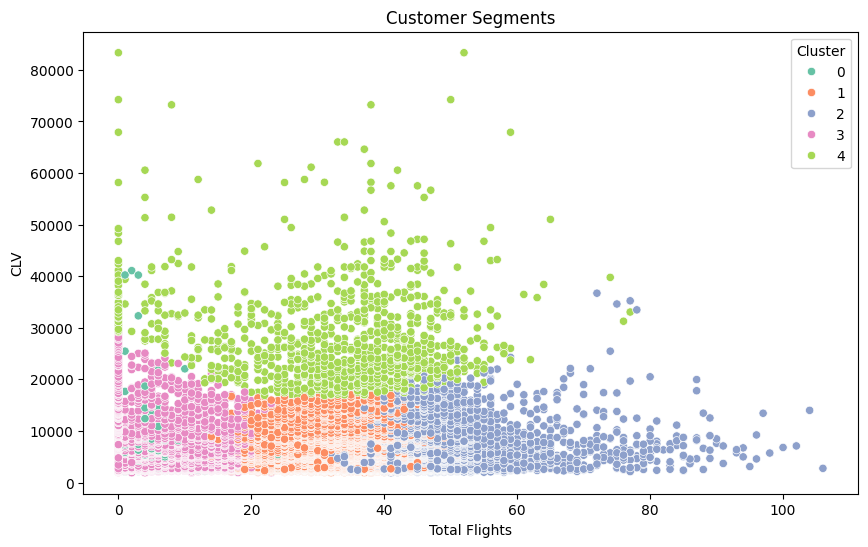

In [53]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=master,
    x='Total Flights',
    y='CLV',
    hue='Cluster',
    palette='Set2'
)
plt.title('Customer Segments')
plt.show()

In [56]:
last_activity = activity.groupby(
    'Loyalty Number'
)['Year'].max().reset_index()

last_activity.columns = [ 'Loyalty Number','Last Active Year']

master = master.merge(last_activity,on='Loyalty Number',how='left')

In [57]:
master['Churn'] = np.where(
    master['Cancellation Year'].notna(),1,0)

In [58]:
X = master[[
    'CLV',
    'Salary',
    'Total Flights',
    'Distance',
    'Points Accumulated',
    'Points Redeemed'
]]

y = master['Churn']

In [59]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train,y_train)

pred = rf.predict(X_test)

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      2935
           1       0.54      0.34      0.42       413

    accuracy                           0.88      3348
   macro avg       0.73      0.65      0.68      3348
weighted avg       0.87      0.88      0.87      3348



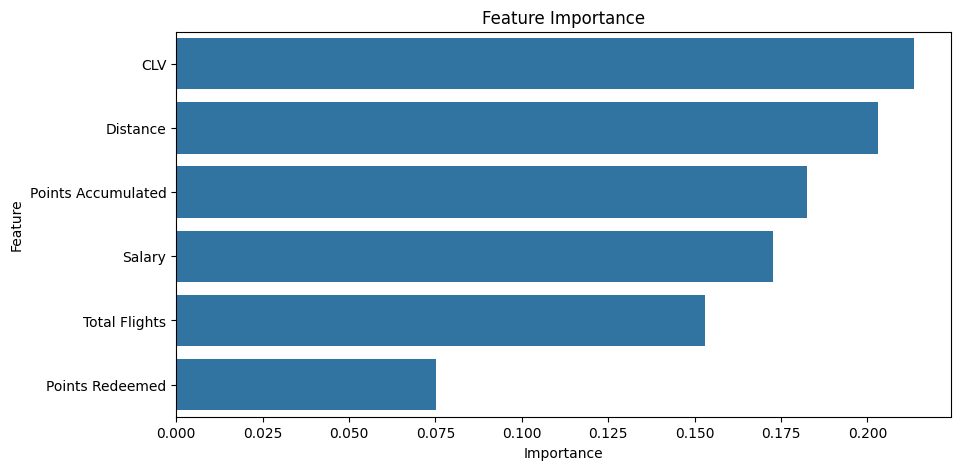

In [62]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

In [63]:
cluster_summary

,CLV,Total Flights,Distance,Points Accumulated,Redemption Ratio
Cluster,,,,,
0,7607.493803,5.802817,7478.394366,7485.299296,0.172522
1,6235.716033,32.940272,48246.885670,48758.035311,0.019423
2,6797.546734,48.997959,76029.269712,83172.216127,0.011971
3,7161.067217,5.972171,8755.694143,8838.458654,0.007603
4,27539.099410,33.086285,49394.796549,50659.826521,0.016904


In [65]:
segment_map = {
    0: 'Reward Seekers',
    1: 'Frequent Travelers',
    2: 'Road Warriors',
    3: 'Dormant Members',
    4: 'Silent VIPs'
}

master['Segment'] = master['Cluster'].map(segment_map)

In [66]:
segment_stats = master.groupby('Segment').agg({
    'CLV':'mean',
    'Total Flights':'mean',
    'Distance':'mean',
    'Points Accumulated':'mean',
    'Churn':'mean'
}).round(2)

segment_stats

,CLV,Total Flights,Distance,Points Accumulated,Churn
Segment,,,,,
Dormant Members,7161.07,5.97,8755.69,8838.46,0.41
Frequent Travelers,6235.72,32.94,48246.89,48758.04,0.04
Reward Seekers,7607.49,5.80,7478.39,7485.30,0.29
Road Warriors,6797.55,49.00,76029.27,83172.22,0.03
Silent VIPs,27539.10,33.09,49394.80,50659.83,0.07


In [67]:
retention_strategy = pd.DataFrame({

'Segment':[
    'Silent VIPs',
    'Road Warriors',
    'Frequent Travelers',
    'Reward Seekers',
    'Dormant Members'
],

'Characteristics':[
    'Highest CLV customers with strong travel activity',
    'Highest flight frequency and travel distance',
    'Regular travelers with stable engagement',
    'Low flight frequency but highest points redemption behavior',
    'Low activity and minimal loyalty program engagement'
],

'Risk Level':[
    'High',
    'Medium',
    'Low',
    'Medium',
    'High'
],

'Recommendation':[
    'Provide personalized retention programs, tier protection, premium lounge access, and exclusive rewards',
    'Encourage premium bookings, business-class upgrades, and tier progression',
    'Maintain engagement through bonus miles, partner offers, and loyalty incentives',
    'Launch targeted points-based promotions and redemption campaigns',
    'Run win-back campaigns, bonus-mile offers, and re-engagement communications'
]

})

retention_strategy

,Segment,Characteristics,Risk Level,Recommendation
0,Silent VIPs,Highest CLV customers with strong travel activity,High,"Provide personalized retention programs, tier ..."
1,Road Warriors,Highest flight frequency and travel distance,Medium,"Encourage premium bookings, business-class upg..."
2,Frequent Travelers,Regular travelers with stable engagement,Low,"Maintain engagement through bonus miles, partn..."
3,Reward Seekers,Low flight frequency but highest points redemp...,Medium,Launch targeted points-based promotions and re...
4,Dormant Members,Low activity and minimal loyalty program engag...,High,"Run win-back campaigns, bonus-mile offers, and..."


In [68]:
churned_customers = master[
    master['Churn'] == 1
]

revenue_at_risk = churned_customers['CLV'].sum()

print("Revenue at Risk:", revenue_at_risk)

Revenue at Risk: 16808382.58


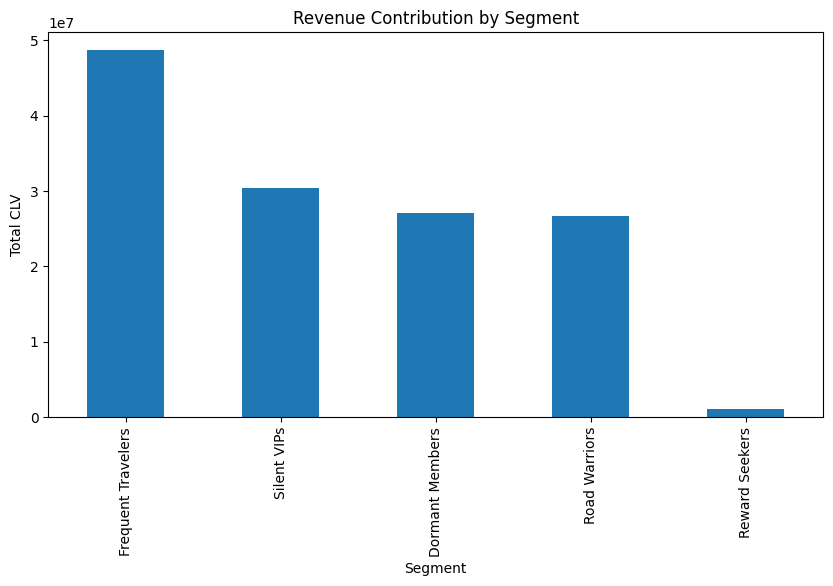

In [69]:
risk_by_segment = master.groupby(
    'Segment'
)['CLV'].sum().sort_values(
    ascending=False
)

risk_by_segment.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Revenue Contribution by Segment')
plt.ylabel('Total CLV')
plt.show()

In [70]:
master['Risk Score'] = (
    0.4*master['Churn'] +
    0.3*(1/(master['Total Flights']+1)) +
    0.3*(master['CLV']/master['CLV'].max())
)

In [71]:
top_risk = master.sort_values(
    'Risk Score',
    ascending=False
)[[
    'Loyalty Number',
    'Segment',
    'CLV',
    'Total Flights',
    'Risk Score'
]].head(20)

top_risk

,Loyalty Number,Segment,CLV,Total Flights,Risk Score
16736,652627,Silent VIPs,83325.38,0,1.000000
9823,844145,Silent VIPs,74228.52,0,0.967248
16730,672917,Silent VIPs,58166.55,0,0.909420
4138,529331,Silent VIPs,49221.43,0,0.877214
9809,943393,Silent VIPs,48356.96,0,0.874102
16718,795743,Silent VIPs,43019.01,0,0.854883
9796,515790,Silent VIPs,42389.01,0,0.852615
4113,248497,Silent VIPs,41143.09,0,0.848129
4106,675419,Silent VIPs,39400.19,0,0.841854
9769,243272,Silent VIPs,36632.53,0,0.831890


### Key Findings

* **CLV alone does not fully capture customer value**; customers with similar CLV often display very different travel behaviors.
* **Five distinct customer segments** were identified: Silent VIPs, Road Warriors, Frequent Travelers, Reward Seekers, and Low Engagement Members.
* **Silent VIPs generate the highest CLV** and should be the top priority for retention efforts.
* **Road Warriors are the most active travelers**, presenting strong opportunities for premium upselling.
* **Reward Seekers respond strongly to loyalty rewards**, making targeted points-based campaigns effective.
* **Low Engagement Members show the highest disengagement risk** and require win-back strategies.
* **Behavioral metrics such as flight activity and reward usage provide deeper insights than CLV or loyalty tier alone.**
* **Segment-specific retention strategies can improve customer retention and marketing efficiency.**


In [111]:
if 'Churn' in master.columns:
    master = master.drop(columns=['Churn'])

In [112]:
activity['Date'] = pd.to_datetime(
    activity['Year'].astype(str) + '-' +
    activity['Month'].astype(str)
)

In [113]:
h1 = activity[
    (activity['Year'] == 2018) &
    (activity['Month'] <= 6)
]

In [115]:
h2 = activity[
    (activity['Year'] == 2018) &
    (activity['Month'] > 6)
]

In [141]:
h1_features = h1.groupby('Loyalty Number').agg({
    'Total Flights':'sum',
    'Distance':'sum',
    'Points Accumulated':'sum',
    'Points Redeemed':'sum',
    'Dollar Cost Points Redeemed':'sum'
}).reset_index()

h1_features.columns = [
    'Loyalty Number',
    'Flights_H1',
    'Distance_H1',
    'Points_H1',
    'Redeemed_H1',
    'DollarRedeemed_H1'
]

In [142]:
h2_activity = h2.groupby(
    'Loyalty Number'
)['Total Flights'].sum().reset_index()

h2_activity.columns = [
    'Loyalty Number',
    'Flights_H2'
]

In [143]:
model_df = h1_features.merge(
    h2_activity,
    on='Loyalty Number',
    how='left'
)

model_df['Flights_H2'] = model_df[
    'Flights_H2'
].fillna(0)

In [144]:
model_df['Churn'] = np.where(
    model_df['Flights_H2'] <= 2,
    1,
    0
)

In [145]:
model_df['Churn'].value_counts()

Churn
0    13786
1     2951
Name: count, dtype: int64

In [146]:
model_df = model_df.merge(
    loyalty,
    on='Loyalty Number',
    how='left'
)

In [147]:
model_df['PointsPerFlight'] = (
    model_df['Points_H1'] /
    (model_df['Flights_H1'] + 1)
)

In [148]:
model_df['DistancePerFlight'] = (
    model_df['Distance_H1'] /
    (model_df['Flights_H1'] + 1)
)

In [149]:
model_df['RedemptionRatio'] = np.where(
    model_df['Points_H1'] > 0,
    model_df['Redeemed_H1'] /
    model_df['Points_H1'],
    0
)

In [150]:
segment_map = master[
    ['Loyalty Number','Cluster']
]

model_df = model_df.merge(
    segment_map,
    on='Loyalty Number',
    how='left'
)

In [161]:
features = [

    'CLV',
    'Salary',

    'Total Flights',
    'Distance',

    'Points Accumulated',
    'Points Redeemed',

    'Redemption Ratio',

    'Distance Per Flight',
    'Points Per Flight',

    'Flights_H1',

    'Cluster',

    'Gender_Male',

    'Marital Status_Married',
    'Marital Status_Single',

    'Education_College',
    'Education_Doctor',
    'Education_High School or Below',
    'Education_Master',

    'Loyalty Card_Nova',
    'Loyalty Card_Star'
]

In [162]:
model_df = pd.get_dummies(
    master,
    columns=[
        'Gender',
        'Marital Status',
        'Education',
        'Loyalty Card'
    ],
    drop_first=True
)

In [167]:
encoded_cols = [
    col for col in model_df.columns
    if col.startswith((
        'Gender_',
        'Marital Status_',
        'Education_',
        'Loyalty Card_'
    ))
]

features.extend(encoded_cols)

In [168]:
print(churn_df.columns)


Index(['Loyalty Number', 'Flights_H1', 'Flights_H2', 'Activity_Change',
       'Churn'],
      dtype='object')


In [169]:
model_df = model_df.merge(
    churn_df[['Loyalty Number', 'Churn']],
    on='Loyalty Number',
    how='left'
)

In [170]:
X = model_df[features]

X = X.fillna(0)

y = model_df['Churn']

In [176]:
X.columns[X.columns.duplicated()]

Index(['Gender_Male', 'Marital Status_Married', 'Marital Status_Single',
       'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Loyalty Card_Nova', 'Loyalty Card_Star', 'Gender_Male',
       'Marital Status_Married', 'Marital Status_Single', 'Education_College',
       'Education_Doctor', 'Education_High School or Below',
       'Education_Master', 'Loyalty Card_Nova', 'Loyalty Card_Star',
       'Gender_Male', 'Marital Status_Married', 'Marital Status_Single',
       'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Loyalty Card_Nova', 'Loyalty Card_Star'],
      dtype='object')

In [177]:
X = X.loc[:, ~X.columns.duplicated()]

In [178]:
print(X.columns[X.columns.duplicated()])

Index([], dtype='object')


In [184]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [186]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [187]:
y_pred = xgb.predict(X_test)

y_prob = xgb.predict_proba(X_test)[:,1]

In [191]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print(
    "Accuracy:",
    accuracy_score(y_test,y_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test,y_prob)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9301075268817204
ROC-AUC: 0.9398636939074003
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2758
           1       0.93      0.65      0.77       590

    accuracy                           0.93      3348
   macro avg       0.93      0.82      0.86      3348
weighted avg       0.93      0.93      0.92      3348

